<a href="https://colab.research.google.com/github/CD-GRUPO3/TA047R-1C2025-GRUPO03/blob/main/TA047R_TP2_GRUPO03_CHPX_ENTREGA_N1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Grupo 3 - Trabajo Práctico 2

**Integrantes:**
- ARIAS, Rafaela Pilar. 112272. rparias@fi.uba.ar.
- BARCALA ROCA, Ramiro. 112478. rbarcala@fi.uba.ar.
- LEMA, Mora. 111831. molema@fi.uba.ar.
- IENCO, Lara Eliana. 111921. lienco@fi.uba.ar.

---

 Bibliografía:
 - https://www.kaggle.com/code/gusthema/titanic-competition-w-tensorflow-decision-forests#Train-model-with-default-parameters
 - https://xgboost.readthedocs.io/en/stable/parameter.html

###Inicialización del entorno


In [ ]:
# Importar las bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento de texto
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [ ]:
!pip install nltk

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Cargamos los datos al Notebook

!gdown 1rbGVg-g0_H4UxviHdM3KFEHv5_DjJd-P
!gdown 19RRGPOcV-gQojb7G3wCtu1pY2Q4fQs_y

Downloading...
From: https://drive.google.com/uc?id=1rbGVg-g0_H4UxviHdM3KFEHv5_DjJd-P
To: /content/test.csv
100% 11.1M/11.1M [00:00<00:00, 35.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=19RRGPOcV-gQojb7G3wCtu1pY2Q4fQs_y
To: /content/train.csv
100% 72.2M/72.2M [00:00<00:00, 169MB/s]


In [ ]:
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

print("Train - Columnas:", train_df.shape[1], "Filas:", train_df.shape[0])
print("Test - Columnas:", test_df.shape[1], "Filas:", test_df.shape[0])

print("\nPrimeras filas del train:")
display(train_df.head())

print("\nColumnas del train:")
print(train_df.columns)

print("\nDistribución de clases:")
print(train_df['sentimiento'].value_counts())


Train - Columnas: 3 Filas: 50000
Test - Columnas: 2 Filas: 8599

Primeras filas del train:


,ID,review_es,sentimiento
0,0,Uno de los otros críticos ha mencionado que de...,positivo
1,1,Una pequeña pequeña producción.La técnica de f...,positivo
2,2,Pensé que esta era una manera maravillosa de p...,positivo
3,3,"Básicamente, hay una familia donde un niño peq...",negativo
4,4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo



Columnas del train:
Index(['ID', 'review_es', 'sentimiento'], dtype='object')

Distribución de clases:
sentimiento
positivo    25000
negativo    25000
Name: count, dtype: int64


Observamos la cantidad de filas nulas en ambos conjuntos (train y test) y la cantidad de filas duplicadas

In [ ]:
print("Cantidad total de valores NaN en el dataset train:", train_df.isnull().sum().sum())
print("Cantidad total de valores NaN en el dataset test:", test_df.isnull().sum().sum())

Cantidad total de valores NaN en el dataset train: 0
Cantidad total de valores NaN en el dataset test: 0


In [ ]:
duplicadas_train = train_df.duplicated().sum()
print("Cantidad de filas duplicadas en el dataset train:", duplicadas_train)

duplicadas_test = test_df.duplicated().sum()
print("Cantidad de filas duplicadas en el dataset test:", duplicadas_test)

Cantidad de filas duplicadas en el dataset train: 0
Cantidad de filas duplicadas en el dataset test: 0


Al no haber duplicadas ni filas con NaN, no tuvimos que hacer nada al respecto.

###Preprocesamiento de los datos


###Limpieza y Tokenización


Veamos si las clases están balanceadas

In [ ]:
train_df['sentimiento'].value_counts()

,count
sentimiento,
positivo,25000
negativo,25000


Separamos el dataset en entrenamiento 80% y test 20%

In [ ]:
X = train_df['review_es']
y = train_df['sentimiento']

#Stratify para balancear la división
X_train_text, X_val_text, y_train, y_val = train_test_split(X,
                                                            y,
                                                            test_size = 0.2,
                                                            random_state = 42,
                                                            stratify = y
)


In [ ]:
y_train.value_counts()

,count
sentimiento,
positivo,20000
negativo,20000


In [ ]:
y_val.value_counts()

,count
sentimiento,
negativo,5000
positivo,5000


In [ ]:
def clean_text(text):
    text = text.lower()
    #re.sub(patron, remplazo, string) --> Devuelve el string con el patron reemplazado

    text = re.sub(r'([.,!?;:])', r' \1 ', text)  #Añade espacio después de puntos y comas si no hay (para que no se junten palabras)
    text = re.sub(r'[^a-záéíóúüñ\s]', '', text) #Reemplaza todo lo que no sea letra o espacio
    text = re.sub(r'\s+[a-záéíóúüñ]\s+', ' ', text)  #Elimina letras sueltas entre espacios
    text = re.sub(r'\s+', ' ', text) #Y si se me juntaron varios espacios, los mergeo en uno
    return text.strip()


Descargamos el modelo de spaCy para español para usarlo en la función de Lemmatización

In [ ]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 20.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

#Cargar el modelo de español
nlp = spacy.load("es_core_news_sm")

#Función de lematización
def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if token.lemma_.isalpha()])

Integramos clean_text y lemmatize_text en una función

In [ ]:
def clean_and_lemmatize(text):
    cleaned = clean_text(text)
    lemmatized = lemmatize_text(cleaned)
    return lemmatized

In [ ]:
#Defino la stoplist
stoplist = stopwords.words("spanish")
stoplist[:15]

['de',
 'la',
 'que',
 'el',
 'en',
 'y',
 'a',
 'los',
 'del',
 'se',
 'las',
 'por',
 'un',
 'para',
 'con']

In [ ]:
def tokenizer(text):
    tokens = word_tokenize(text, language="spanish")
    return [
        t.lower()
        for t in tokens
        if t.isalpha()
        and t.lower() not in stoplist
        and 2 <= len(t) <= 20
        and len(set(t.lower())) > 1  #Descarta tokens con todas las letras iguales, ej: "aa", "aaa"
    ]

In [ ]:
#Para chequear que estamos haciendo las cosas bien
ejemplo = X_train_text.sample(1).iloc[0]

print("Crítica original:")
print(ejemplo)
print("\nTexto limpio:")
print(clean_text(ejemplo))
print("\nTokens:")
print(tokenizer(clean_text(ejemplo)))

Crítica original:
Lo que dibujó una experiencia dolorosa. Eso es más de dos horas de mi vida, nunca volveré. Este delicia del director del festival de cine se encuentra con el uso excesivo de la larga disparo lento ... Sin embargo, eso no es lo único que hace un guión..Lavoide esta película a toda costa.

Texto limpio:
lo que dibujó una experiencia dolorosa eso es más de dos horas de mi vida nunca volveré este delicia del director del festival de cine se encuentra con el uso excesivo de la larga disparo lento sin embargo eso no es lo único que hace un guión lavoide esta película toda costa

Tokens:
['dibujó', 'experiencia', 'dolorosa', 'dos', 'horas', 'vida', 'nunca', 'volveré', 'delicia', 'director', 'festival', 'cine', 'encuentra', 'uso', 'excesivo', 'larga', 'disparo', 'lento', 'embargo', 'único', 'hace', 'guión', 'lavoide', 'película', 'toda', 'costa']


In [ ]:
import warnings
warnings.filterwarnings("ignore", message="The parameter 'token_pattern' will not be used*")

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    preprocessor = clean_and_lemmatize,  #Aplicamos limpieza + lematización
    tokenizer = tokenizer,
    min_df = 10,
    max_df = 0.8,
)

X_train_vect = vectorizer.fit_transform(X_train_text)
X_val_vect = vectorizer.transform(X_val_text)

print("Cantidad de textos en entrenamiento:", X_train_vect.shape[0])
print("Cantidad de palabras distintas en entrenamiento:", X_train_vect.shape[1])
print("\n")

contador_palabras = np.array(X_train_vect.sum(axis = 0)).flatten() #Sumamos frecuencias por palabra
palabras = vectorizer.get_feature_names_out() #Obtenemos las palabras del vocabulario

#Armamos un DataFrame ordenado
freq_df = pd.DataFrame({'palabra': palabras, 'frecuencia': contador_palabras})
freq_df = freq_df.sort_values(by = 'frecuencia', ascending = False)

#Mostramos las 20 más frecuentes
display(freq_df.head(20))

Previo a establecer y entrenar los modelos, implementamos una función para poder observar las métricas en el conjunto train y test.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar(y_true, y_pred, nombre):
    print(f"--- {nombre} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print()

##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

Vamos a buscar los mejores hiperparámetros utilizando GridSearch aplicando Cross Validation con 5 folds

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 3]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    param_grid,
    cv = 5,               #5-fold cross-validation
    scoring = 'f1_macro',
    n_jobs = -1,
)

grid_rf.fit(X_train_vect, y_train)

print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor score de validación:", grid_rf.best_score_)

Mejores parámetros: {'criterion': 'gini', 'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Mejor score de validación: 0.8334945232164543


Predecimos en el conjunto de train

In [ ]:
#Usamos el mejor modelo encontrado por GridSearch
best_rf = grid_rf.best_estimator_

#Predecimos
y_val_pred = best_rf.predict(X_val_vect)
y_train_pred = best_rf.predict(X_train_vect)

#Evaluamos las métricas
print(classification_report(y_val, y_val_pred))

print("\n")
print("*"*20)
print("\n")

evaluar(y_train, y_train_pred, "Random Forest - Train")
evaluar(y_val, y_val_pred, "Random Forest - Validación")

              precision    recall  f1-score   support

    negativo       0.86      0.81      0.83      5000
    positivo       0.82      0.87      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



********************


--- Random Forest - Train ---
Accuracy : 0.9435
Precision: 0.9134
Recall   : 0.9800
F1 Score : 0.9455

--- Random Forest - Validación ---
Accuracy : 0.8378
Precision: 0.8181
Recall   : 0.8688
F1 Score : 0.8427



Observamos las matrices de confusión para tener más claro su rendimiento:

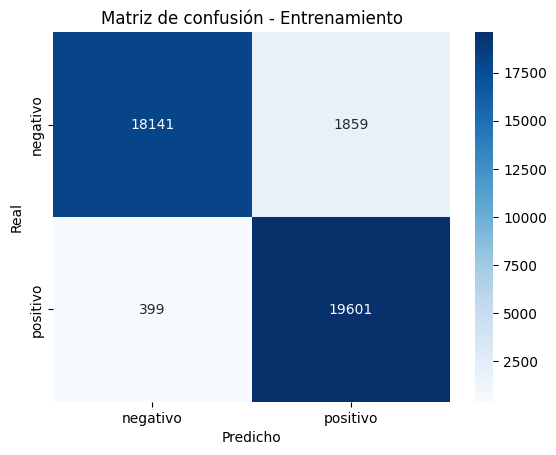

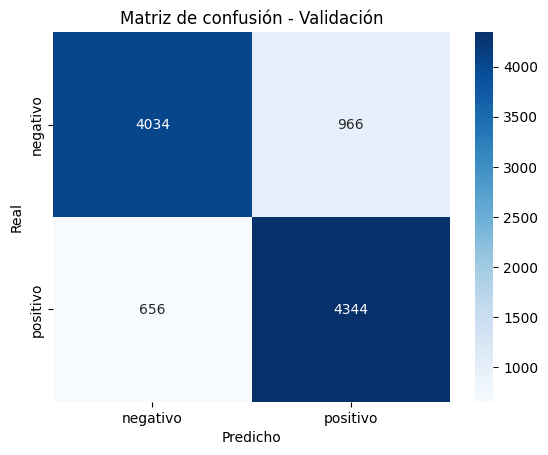

In [ ]:
#Matrices de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Entrenamiento
cm_train = confusion_matrix(y_train, y_train_pred, labels=best_rf.classes_)
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.title("Matriz de confusión - Entrenamiento")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

print("\n")

#Validación
cm_val = confusion_matrix(y_val, y_val_pred, labels=best_rf.classes_)
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.title("Matriz de confusión - Validación")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

Predecimos sobre el conjunto de test

In [ ]:
#Vectorizamos los textos de test
X_test_vect = vectorizer.transform(test_df["review_es"])

#Predecimos con el mejor modelo
y_test_pred = best_rf.predict(X_test_vect)

#Creamos el dataframe para submissionz
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "sentimiento": y_test_pred
})

#Guardamos el archivo CSV para subir a Kaggle
submission.to_csv("submission_rf.csv", index = False)

In [ ]:
#Con esto se descarga el archivo
from google.colab import files
files.download('submission_rf.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##XGBoost

In [ ]:
!pip install xgboost
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

from collections import defaultdict

Para el XGBoost es necesario que las clases estén encodeadas como números y no texto, por lo que usamos label encoder para pasar el sentimiento negativo a 0 y el positivo a 1.

In [ ]:
#Encodeamos las clases pos y neg para el XGBoost
#negativo → 0   ///   positivo → 1
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

#Hiperparámetros --> Espacio amplio de búsqueda
param_dist = {
    'n_estimators': [700, 800, 900],
    'max_depth': np.arange(3, 10),
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'subsample': np.linspace(0.5, 1.0, 6),
    'colsample_bytree': np.linspace(0.5, 1.0, 6),
    'gamma': np.linspace(0, 5, 6)
}

xgb_clf = XGBClassifier(random_state=42)

xgb_random_search = RandomizedSearchCV(
    estimator = xgb_clf,
    param_distributions = param_dist,
    n_iter = 50,
    scoring = 'f1',
    cv = 4,
    verbose = 1,
    random_state = 42,
    n_jobs = -1
)

xgb_random_search.fit(X_train_vect, y_train_enc)

results = pd.DataFrame(xgb_random_search.cv_results_)
top5 = results.sort_values(by='rank_test_score').head(5)
top5_params = top5['params'].tolist()

In [ ]:
for param in top5_params:
    print(param)

Ahora hacemos Grid Search con los 5 mejores parámetros

In [ ]:
from sklearn.model_selection import GridSearchCV
base_params = top5_params[0]

#Ajustamos rangos alrededor del mejor conjunto
grid_params = {
    'n_estimators': [base_params['n_estimators'] - 50, base_params['n_estimators'], base_params['n_estimators'] + 50],
    'max_depth': [base_params['max_depth'] - 1, base_params['max_depth'], base_params['max_depth'] + 1],
    'learning_rate': [round(base_params['learning_rate'] * f, 3) for f in [0.8, 1.0, 1.2]],
    'subsample': [base_params['subsample']],
    'colsample_bytree': [base_params['colsample_bytree']],
    'gamma': [base_params['gamma']]
}

xgb_grid_search = GridSearchCV(
    estimator = xgb_clf,
    param_grid = grid_params,
    scoring = 'f1',
    cv = 4,
    verbose = 1,
    n_jobs = -1
)

xgb_grid_search.fit(
    X_train_vect,
    y_train_enc,
    eval_set=[(X_val_vect, y_val_enc)],
    eval_metric='logloss',
    early_stopping_rounds=10,
    verbose=True
)

In [ ]:
#Matrices de confusión

#Entrenamiento
cm_train = confusion_matrix(y_train, y_train_pred, labels=le.classes_)
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matriz de confusión - Entrenamiento (XGBoost)")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

print("\n")

#Validación
cm_val = confusion_matrix(y_val, y_val_pred, labels=le.classes_)
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matriz de confusión - Validación (XGBoost)")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

In [ ]:
#Predicción y evaluación, de 0 y 1 se vuelve a neg y pos
y_train_pred = le.inverse_transform(xgb_grid_search.predict(X_train_vect))
y_val_pred = le.inverse_transform(xgb_grid_search.predict(X_val_vect))

print(classification_report(y_val, y_val_pred))

print("\n")
print("*"*20)
print("\n")

evaluar(y_train, y_train_pred, "XGBoost - Train")
evaluar(y_val, y_val_pred, "XGBoost - Validación")

#Predecimos sobre test
X_test_vect = vectorizer.transform(test_df["review_es"])
y_test_pred = xgb_grid_search.predict(X_test_vect)
y_test_pred_labels = le.inverse_transform(y_test_pred)

#Guardamos CSV para Kaggle
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "sentimiento": y_test_pred_labels
})
submission.to_csv("submission_xgb.csv", index = False)

In [ ]:
# Con esto se descarga el archivo
from google.colab import files
files.download('submission_xgb.csv')